# CEPU China Mainland - Exploratory Data Analysis

This notebook explores the China Economic Policy Uncertainty (CEPU) dataset from mainland newspaper coverage.

**Dataset:** `cepu-mainland-papers.xlsx` (4 sheets, using first 3: EPU 1949-1978, EPU 1979-1999, EPU 2000 onwards)

**Description:** Monthly EPU index for China based on mainland newspaper analysis.

**Citation:** Davis, S.J., Liu, D., & Sheng, X.S. (2019). *Economic Policy Uncertainty in China Since 1949: The View from Mainland Newspapers*.

**Tasks:**
1. Load and combine first 3 sheets into one unified dataset
2. Export to CSV
3. Basic exploratory analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_RAW = Path('../../../data/raw')
EXCEL_PATH = DATA_RAW / 'cepu-mainland-papers.xlsx'

## 1. Load and Combine Sheets

In [2]:
# Read Excel and list sheets
xls = pd.ExcelFile(EXCEL_PATH)
print("Sheet names:", xls.sheet_names)

# Load first 3 sheets (exclude TPU)
sheets_to_use = xls.sheet_names[:3]
print(f"\nUsing sheets: {sheets_to_use}")

dfs = []
for sheet in sheets_to_use:
    df_sheet = pd.read_excel(xls, sheet_name=sheet, usecols=[0, 1, 2])
    df_sheet.columns = ['year', 'month', 'EPU']
    print(f"  {sheet}: {len(df_sheet)} rows, {df_sheet['year'].min()}-{df_sheet['year'].max()}")
    dfs.append(df_sheet)

# Combine
df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(['year', 'month']).reset_index(drop=True)

# Create proper date column
df['Date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# Reorder columns
df = df[['Date', 'year', 'month', 'EPU']]

print(f"\nCombined dataset: {len(df)} rows")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Duplicates: {df.duplicated(subset=['year', 'month']).sum()}")

display(df.head())
display(df.tail())

Sheet names: ['EPU 1949-1978', 'EPU 1979-1999', 'EPU 2000 onwards', 'TPU 2000 onwards']

Using sheets: ['EPU 1949-1978', 'EPU 1979-1999', 'EPU 2000 onwards']
  EPU 1949-1978: 351 rows, 1949-1978
  EPU 1979-1999: 252 rows, 1979-1999
  EPU 2000 onwards: 312 rows, 2000-2025

Combined dataset: 915 rows
Date range: 1949-10-01 00:00:00 to 2025-12-01 00:00:00
Duplicates: 0


,Date,year,month,EPU
0,1949-10-01,1949,10,87.237322
1,1949-11-01,1949,11,40.545627
2,1949-12-01,1949,12,40.074743
3,1950-01-01,1950,1,39.424100
4,1950-02-01,1950,2,200.476594


,Date,year,month,EPU
910,2025-08-01,2025,8,301.270330
911,2025-09-01,2025,9,221.757773
912,2025-10-01,2025,10,522.430956
913,2025-11-01,2025,11,454.235919
914,2025-12-01,2025,12,420.053392


## 2. Export to CSV

In [14]:
# Export combined dataset to CSV
csv_path = DATA_RAW / 'cepu-china-mainland.csv'
df.to_csv(csv_path, index=False)

print(f"✓ Exported to: {csv_path}")
print(f"  Rows: {len(df)}")
print(f"  Columns: {list(df.columns)}")

# Verify
df_check = pd.read_csv(csv_path, parse_dates=['Date'])
print(f"\n✓ Verification: {df_check.shape[0]} rows loaded from CSV")
display(df_check.head())

✓ Exported to: ../../../data/raw/cepu-china-mainland.csv
  Rows: 915
  Columns: ['Date', 'year', 'month', 'EPU', 'MA_12m', 'decade']

✓ Verification: 915 rows loaded from CSV


,Date,year,month,EPU,MA_12m,decade
0,1949-10-01,1949,10,87.237322,NaN,1940
1,1949-11-01,1949,11,40.545627,NaN,1940
2,1949-12-01,1949,12,40.074743,NaN,1940
3,1950-01-01,1950,1,39.424100,NaN,1950
4,1950-02-01,1950,2,200.476594,NaN,1950


## 3. Data Overview

In [4]:
print("Dataset Shape:", df.shape)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total months: {len(df)}")
print(f"Total years: {df['year'].nunique()}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nZero EPU values: {(df['EPU'] == 0).sum()}")
print(f"\nDataset Info:")
df.info()

Dataset Shape: (915, 4)

Date range: 1949-10-01 00:00:00 to 2025-12-01 00:00:00
Total months: 915
Total years: 77

Missing values:
Date     0
year     0
month    0
EPU      2
dtype: int64

Zero EPU values: 165

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    915 non-null    datetime64[ns]
 1   year    915 non-null    int64         
 2   month   915 non-null    int64         
 3   EPU     913 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 28.7 KB


## 4. Descriptive Statistics

In [5]:
print("Descriptive Statistics for CEPU:")
display(df['EPU'].describe())

print("\nAdditional Statistics:")
print(f"Skewness: {df['EPU'].skew():.4f}")
print(f"Kurtosis: {df['EPU'].kurtosis():.4f}")
print(f"Coefficient of Variation: {df['EPU'].std() / df['EPU'].mean():.4f}")

Descriptive Statistics for CEPU:


count    913.000000
mean     120.406514
std      122.924888
min        0.000000
25%       38.780875
50%       89.033615
75%      160.429720
max      789.137531
Name: EPU, dtype: float64


Additional Statistics:
Skewness: 1.7437
Kurtosis: 3.7459
Coefficient of Variation: 1.0209


## 5. Time Series Visualization

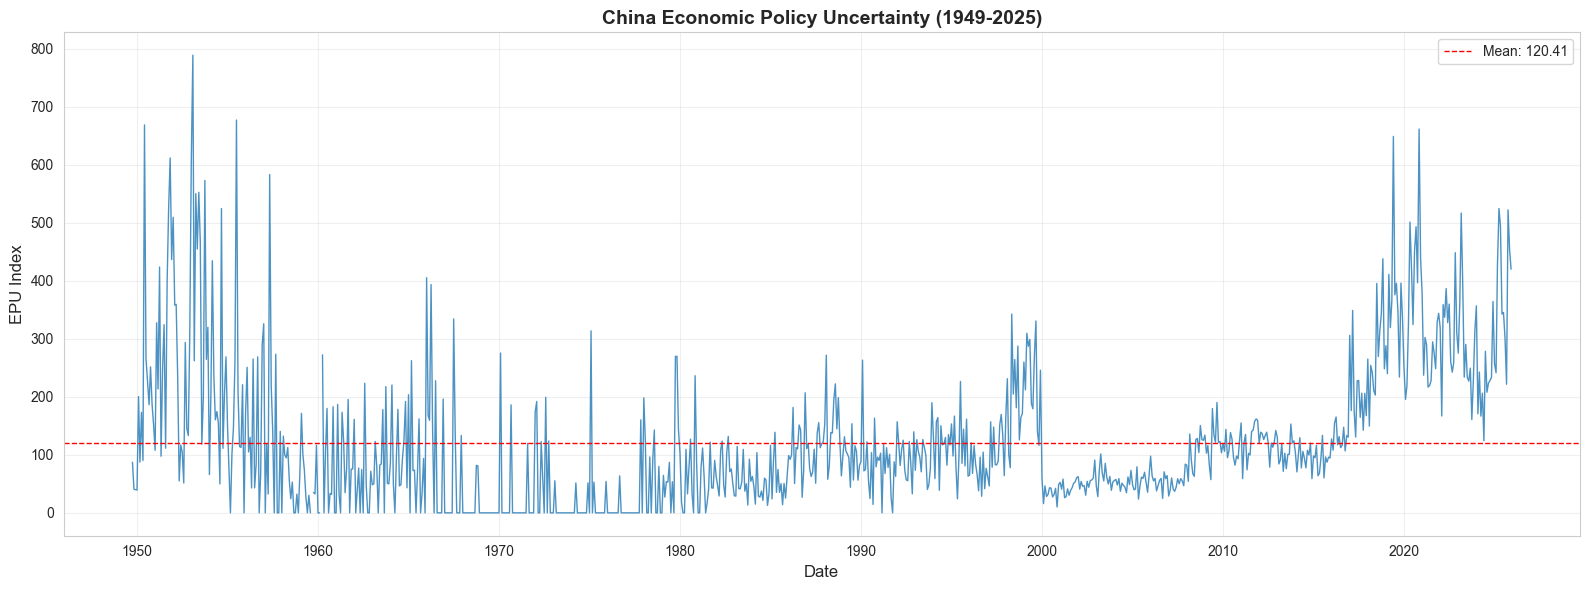

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['EPU'], linewidth=1, alpha=0.8)
ax.axhline(df['EPU'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df["EPU"].mean():.2f}')
ax.set_title('China Economic Policy Uncertainty (1949-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('EPU Index', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

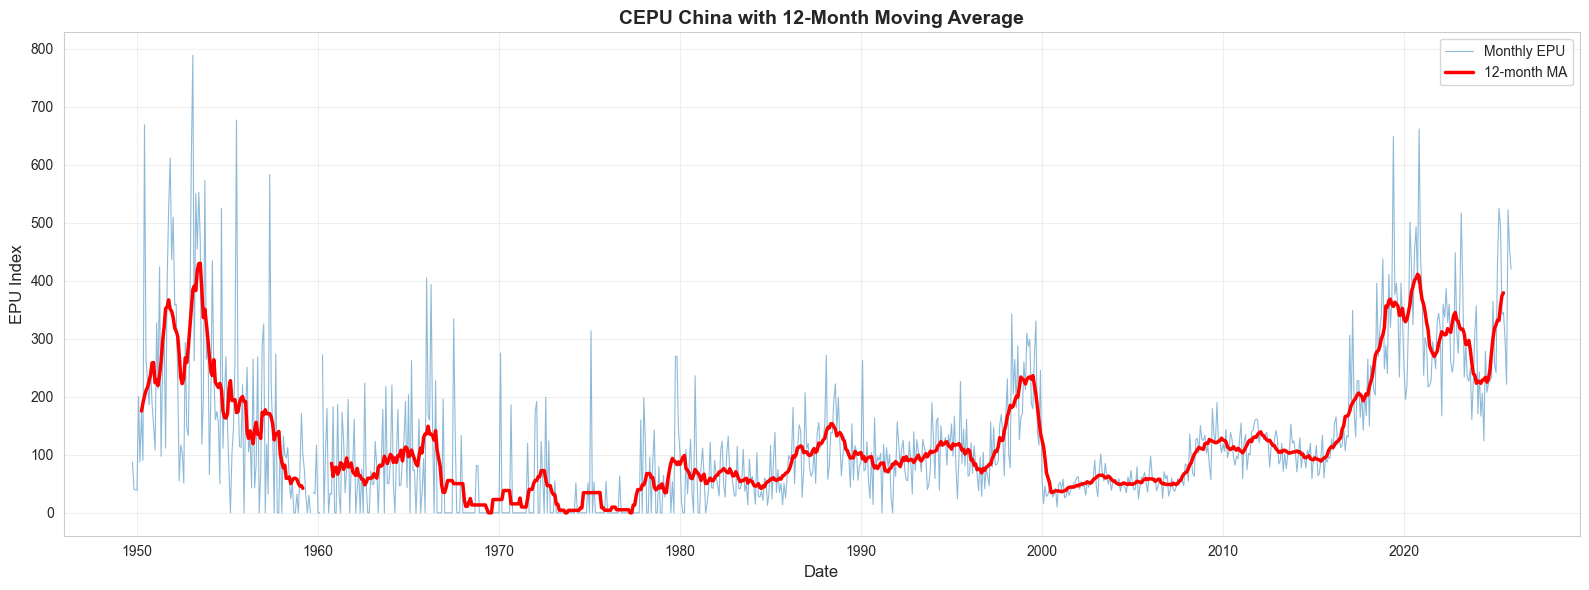

In [7]:
# With 12-month moving average
df['MA_12m'] = df['EPU'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['EPU'], linewidth=0.8, alpha=0.5, label='Monthly EPU')
ax.plot(df['Date'], df['MA_12m'], linewidth=2.5, label='12-month MA', color='red')
ax.set_title('CEPU China with 12-Month Moving Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('EPU Index', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Distribution Analysis

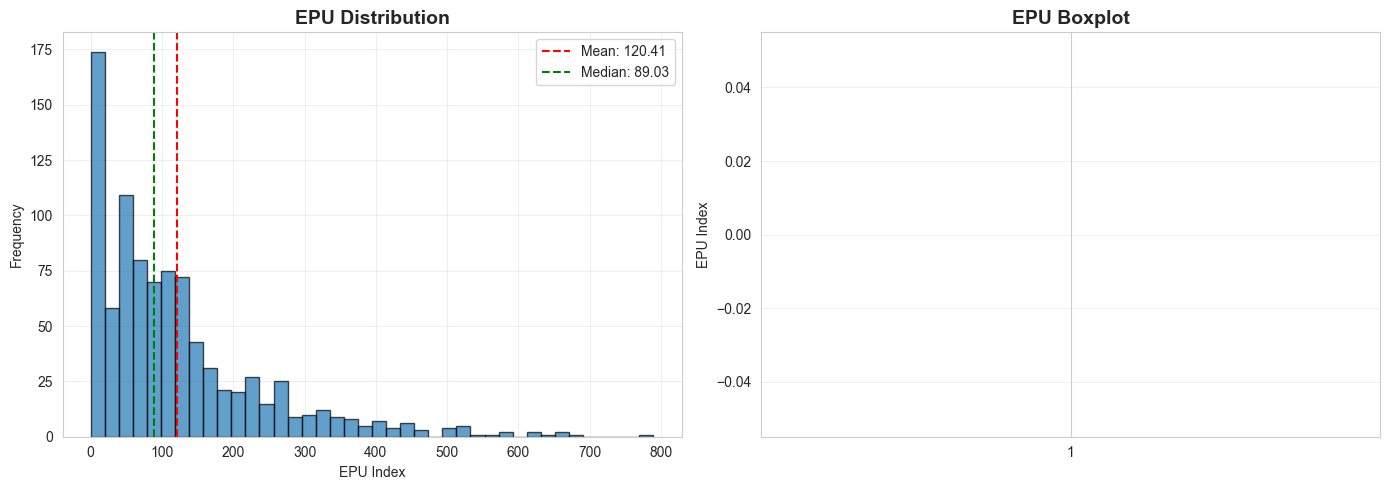

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['EPU'], bins=40, edgecolor='black', alpha=0.7)
axes[0].axvline(df['EPU'].mean(), color='red', linestyle='--', label=f'Mean: {df["EPU"].mean():.2f}')
axes[0].axvline(df['EPU'].median(), color='green', linestyle='--', label=f'Median: {df["EPU"].median():.2f}')
axes[0].set_title('EPU Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('EPU Index')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
bp = axes[1].boxplot(df['EPU'], patch_artist=True, vert=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
axes[1].set_title('EPU Boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('EPU Index')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Temporal Patterns

EPU by Decade:


,mean,std,min,max,count
decade,,,,,
1940,55.952564,27.094418,40.074743,87.237322,3
1950,199.049659,177.276281,0.000000,789.137531,119
1960,67.692263,89.407588,0.000000,405.479701,119
1970,33.436018,68.625835,0.000000,313.836691,120
1980,81.069336,53.726625,0.000000,271.979233,120
1990,120.410092,71.231832,0.000000,342.785276,120
2000,63.140580,32.949943,10.111333,190.316103,120
2010,163.195282,99.801124,58.899236,649.072536,120
2020,314.872830,105.946825,124.295467,661.828048,72


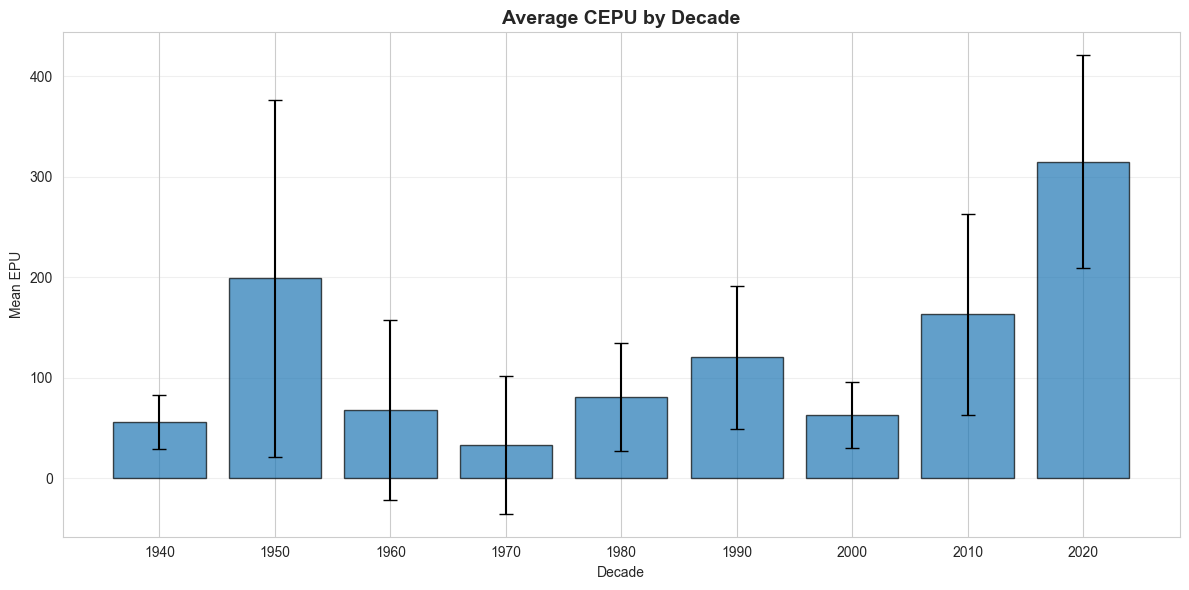

In [9]:
# Decade statistics
df['decade'] = (df['year'] // 10) * 10
decade_stats = df.groupby('decade')['EPU'].agg(['mean', 'std', 'min', 'max', 'count'])
print("EPU by Decade:")
display(decade_stats)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(decade_stats.index.astype(str), decade_stats['mean'], alpha=0.7, edgecolor='black',
       yerr=decade_stats['std'], capsize=5)
ax.set_title('Average CEPU by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Mean EPU')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

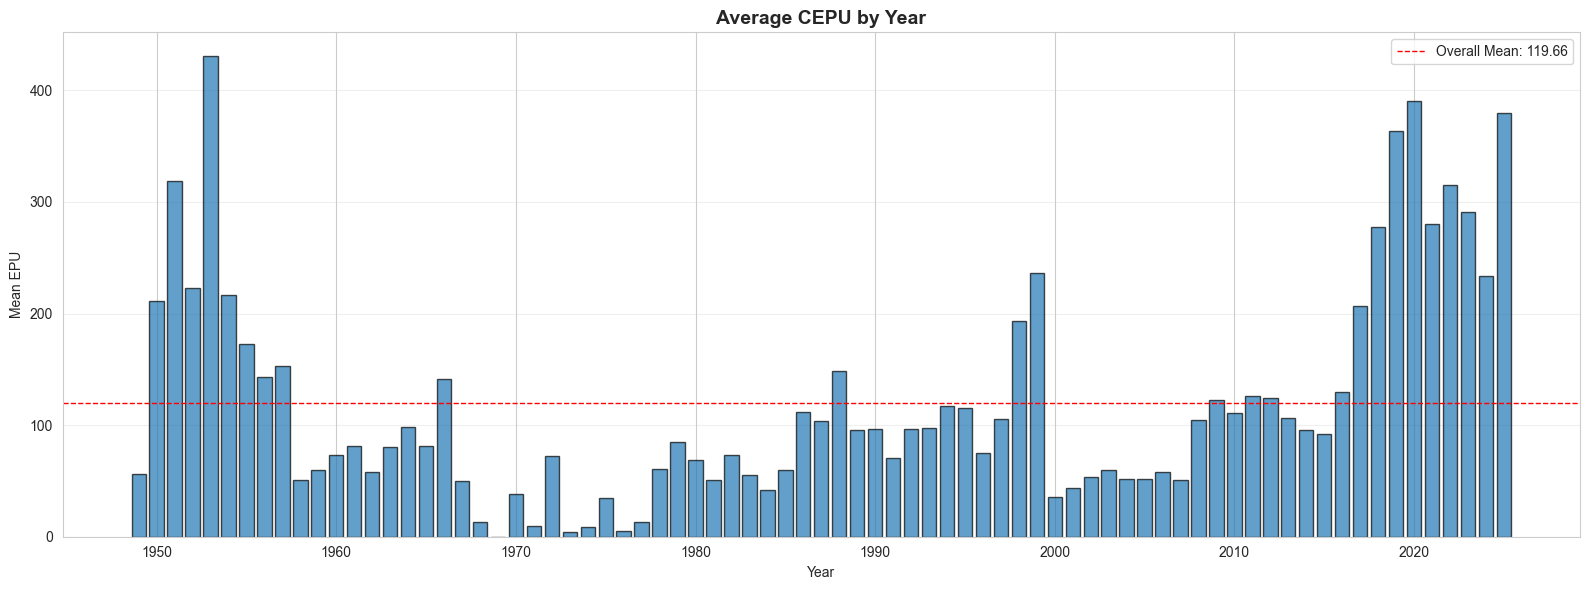

In [10]:
# Yearly average
yearly = df.groupby('year')['EPU'].mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(yearly.index, yearly.values, alpha=0.7, edgecolor='black', width=0.8)
ax.axhline(yearly.mean(), color='red', linestyle='--', linewidth=1, label=f'Overall Mean: {yearly.mean():.2f}')
ax.set_title('Average CEPU by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean EPU')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Key Events Analysis

In [11]:
# Top 10 highest uncertainty months
top_10 = df.nlargest(10, 'EPU')[['Date', 'year', 'month', 'EPU']]
print("Top 10 Highest Uncertainty Months:")
display(top_10)

# Top 10 lowest uncertainty months (excluding zeros)
non_zero = df[df['EPU'] > 0]
bottom_10 = non_zero.nsmallest(10, 'EPU')[['Date', 'year', 'month', 'EPU']]
print("\nTop 10 Lowest Uncertainty Months (excl. zeros):")
display(bottom_10)

Top 10 Highest Uncertainty Months:


,Date,year,month,EPU
40,1953-02-01,1953,2,789.137531
69,1955-07-01,1955,7,677.324192
8,1950-06-01,1950,6,668.868176
853,2020-11-01,2020,11,661.828048
836,2019-06-01,2019,6,649.072536
39,1953-01-01,1953,1,612.737178
25,1951-11-01,1951,11,611.993560
91,1957-05-01,1957,5,583.335132
48,1953-10-01,1953,10,573.214632
44,1953-06-01,1953,6,552.719998



Top 10 Lowest Uncertainty Months (excl. zeros):


,Date,year,month,EPU
613,2000-11-01,2000,11,10.111333
421,1984-11-01,1984,11,12.895461
408,1983-10-01,1983,10,13.561382
431,1985-09-01,1985,9,13.970856
491,1990-09-01,1990,9,14.464801
413,1984-03-01,1984,3,14.983392
604,2000-02-01,2000,2,15.919179
381,1981-07-01,1981,7,16.455089
364,1980-02-01,1980,2,17.779927
418,1984-08-01,1984,8,21.444646


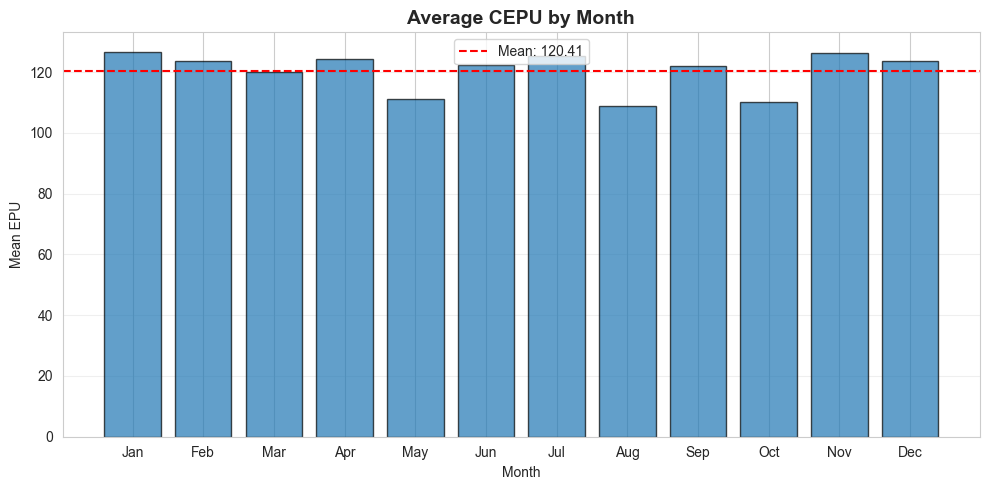

In [12]:
# Monthly seasonality
monthly_avg = df.groupby('month')['EPU'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(monthly_avg.index, monthly_avg.values, alpha=0.7, edgecolor='black')
ax.axhline(monthly_avg.mean(), color='red', linestyle='--', label=f'Mean: {monthly_avg.mean():.2f}')
ax.set_title('Average CEPU by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean EPU')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 9. Summary

In [13]:
print("=" * 60)
print("CEPU CHINA MAINLAND - EXPLORATION SUMMARY")
print("=" * 60)
print(f"\n✓ Combined 3 Excel sheets into unified dataset")
print(f"\n✓ Dataset:")
print(f"  - Rows: {len(df)}")
print(f"  - Frequency: Monthly")
print(f"  - Date range: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
print(f"  - EPU mean: {df['EPU'].mean():.2f}")
print(f"  - EPU std: {df['EPU'].std():.2f}")
print(f"  - Zero values: {(df['EPU'] == 0).sum()}")
print(f"\n✓ Exported to: data/raw/cepu-china-mainland.csv")
print("\n" + "=" * 60)

CEPU CHINA MAINLAND - EXPLORATION SUMMARY

✓ Combined 3 Excel sheets into unified dataset

✓ Dataset:
  - Rows: 915
  - Frequency: Monthly
  - Date range: 1949-10 to 2025-12
  - EPU mean: 120.41
  - EPU std: 122.92
  - Zero values: 165

✓ Exported to: data/raw/cepu-china-mainland.csv

